In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

215.40769933101


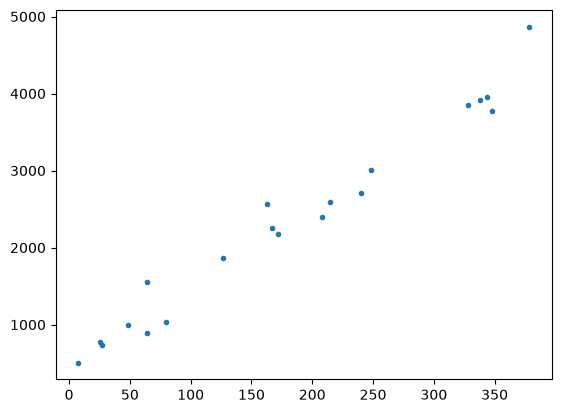

In [47]:
# Primeiro vamos fazer alguns dados sintéticos
a, b = 10, 524
N = 20
random = np.random.default_rng()
x = random.uniform(0, 500, N)
# Dados observados
yo = a * x + b
# Ruído
noise_std = 0.05 * np.abs(yo).max()
print(noise_std)
noise = random.normal(0, noise_std, N)
# Adicionando o ruído ao dado observado
yo = yo + noise
# Plota o dado para observar sua distribuição
plt.plot(x,yo, '.')

## Primeira ordem

$f_i(\bar{p}) = p_2 \times{} x_i + p_1$

In [48]:
# Vamos construir nossa matriz jacobiana
G = np.empty((N, 2))
# Adicionamos valores a primeira coluna 
G[:,0] = 1
# Adicionamos valores a segunda coluna
G[:,1] = x

In [49]:
# Vamos usar a função np.linalg.solv() para tentar solucionar nosso sistema de equações linear
p = np.linalg.solve(G.T @ G, G.T @ yo)
# Vamos printar p e comparar com a e b
print(p)

[466.32528209  10.31783022]


## Ordem arbitraria

$f_i(\bar{p}) = \sum_{k=0}^{L}{p_k \times{} x^k}$

In [50]:
L = 1
G = np.empty((N, L + 1))
# Vamos construir a matriz G usando um loop
for k in range(L+1):
    G[:,k] = x ** k
p = np.linalg.solve(G.T @ G, G.T @ yo)

In [51]:
# Vamos calcular nossos dados preditos
y = G @ p
# Vamos calcular os resíduos subtraindo os dados observados dos preditos
residuals = yo - y
# Vamos calcular a norma dos nossos resíduos
np.linalg.norm(residuals)

np.float64(969.3427823433259)

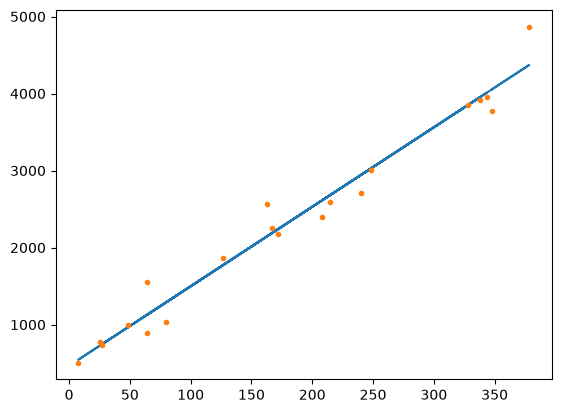

In [52]:
# Vamos plotar os dados observados e os preditos
plt.plot(x, y, "-")
plt.plot(x, yo, ".")

In [53]:
# Vamos observar a "cara" dos nossos resíduos
print(residuals.mean())
print(residuals.std())

-3.922195901395753e-13
216.75163548184594


## Overfitting

In [59]:
L = 10
G = np.empty((N, L + 1))
# Vamos construir a matriz G usando um loop
for k in range(L+1):
    G[:,k] = x ** k
p = np.linalg.solve(G.T @ G, G.T @ yo)

In [60]:
# Podemos fazer da seguinte forma para fittar um polinomio que qualquer ordem para nossos dados
x_ordered = np.linspace(-50 + x.min(), 50 + x.max(), 200)
y_ordered = np.zeros(x_ordered.shape)
for k in range(L+1):
    y_ordered += p[k] * x_ordered ** k

(405.8116674326555, 5843.304931675044)

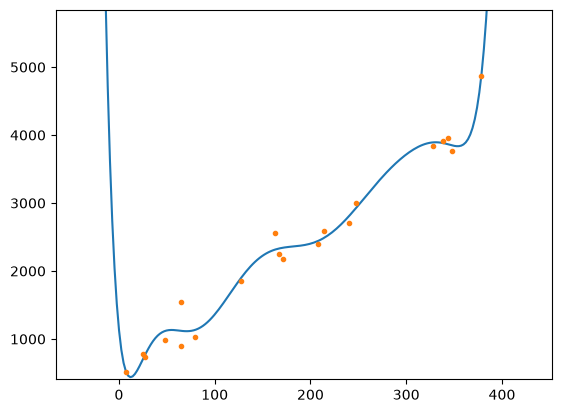

In [62]:
# Vamos plotar para ver como fica
plt.plot(x_ordered, y_ordered, '-')
plt.plot(x, yo, '.')
plt.ylim(0.8 * yo.min(), 1.2 * yo.max())

Com isso mostramos que podemos ir a um polinomio de qualquer ordem para ajustar os nossos dados.
Contudo, isso pode não ser o melhor modelo. Usando um polinomio de ordem 10 por exemplo, nos ajustamos todos os dados, incluindo o seus ruídos